# Fitting Io in the image plane

In [1]:
# jax ecosystem
import jax
from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 250
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


NVIDIA GeForce RTX 2080 Ti


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/IO/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/IO/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/IO/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)

sci_files = []
cal_files = []

for file in files:
    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :10] = 1
    file["BADPIX"].data[:, -10:] = 1
    file["BADPIX"].data[:10, :] = 1
    file["BADPIX"].data[-10:, :] = 1

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        file["BADPIX"].data[43, 45] = 1
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 18)

In [4]:
from tqdm.notebook import tqdm
from scipy.ndimage import gaussian_filter
from photutils.psf.matching import TukeyWindow
import numpy as onp

source_size = 101  # pixels
npix = source_size

pixel_grid = onp.zeros((npix, npix))
basis = onp.zeros((npix * npix, npix * npix))

mask = TukeyWindow(alpha=0.0)((npix, npix))

# plt.imshow(mask)
# plt.colorbar()
# plt.show()

for j in tqdm(range(npix)):
    for i in range(npix):
        pixel_grid = 0 * onp.ones_like(pixel_grid)
        pixel_grid[j, i] = 1
        convolved = gaussian_filter(pixel_grid, sigma=1.0) * mask
        # convolved = pixel_grid
        basis[:, j * npix + i] = convolved.flatten()

eigvals, eigvecs = np.linalg.eigh(basis)
eigvals, eigvecs = eigvals.real[::-1], eigvecs.real[..., ::-1]
basis_dict = {"eigvals": eigvals, "eigvecs": eigvecs}

  0%|          | 0/101 [00:00<?, ?it/s]

In [5]:
basis_dict

# np.save(cache + "im_basis101_1pix_M.npy", basis_dict)

{'eigvals': Array([ 0.99887566,  0.99714808,  0.99714808, ..., -0.05907315,
        -0.05907315, -0.05907315], dtype=float64),
 'eigvecs': Array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float64)}

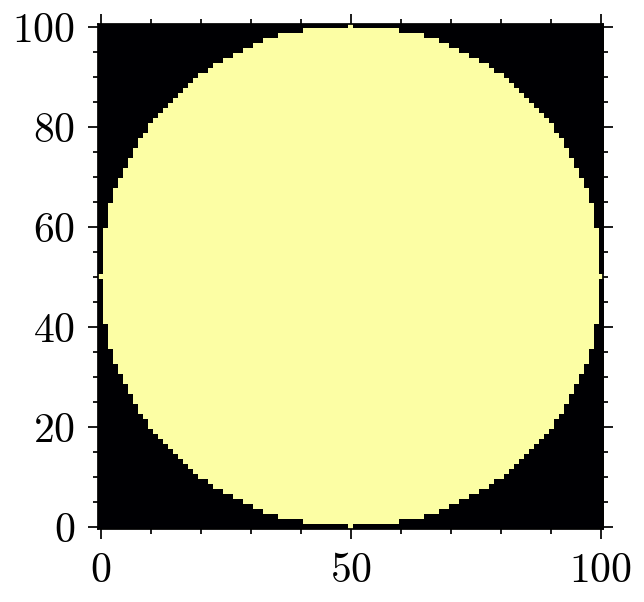

In [6]:
plt.imshow(mask)

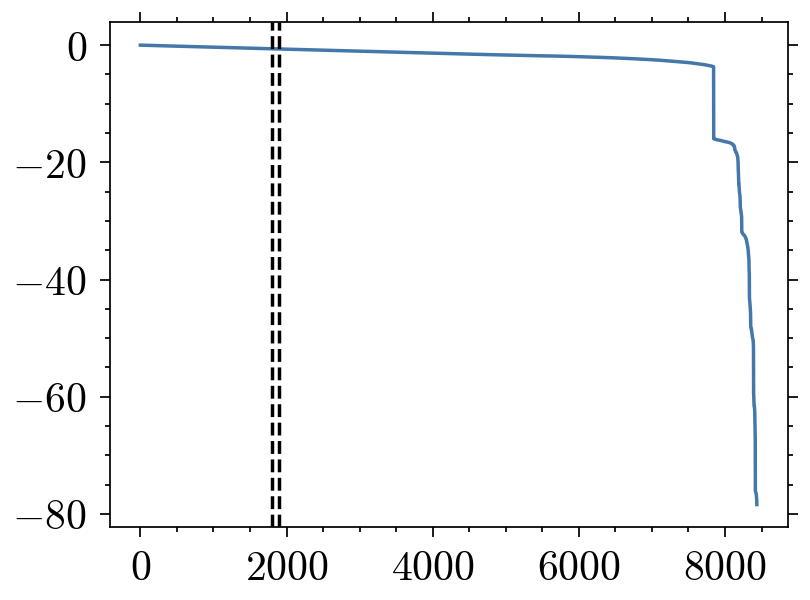

In [7]:
n1, n2 = 1800, 1900

plt.plot(np.log10(eigvals))
plt.axvline(n1, color="k", ls="--")
plt.axvline(n2, color="k", ls="--")
# plt.ylim(-5, 1)
plt.show()

# d = 10
# upto = 2000
# for i in range(0, int(upto / d), 2):
#     fig, axes = plt.subplots(1, 2, figsize=(9, 3))
#     im = axes[0].imshow(
#         eigvecs[:, i * d].reshape((npix, npix)),
#         cmap="coolwarm",
#         norm=mpl.colors.CenteredNorm(),
#     )
#     axes[0].set_title(i * d)
#     fig.colorbar(im, ax=axes[0])

#     im = axes[1].imshow(
#         eigvecs[:, (i + 1) * d].reshape((npix, npix)),
#         cmap="coolwarm",
#         norm=mpl.colors.CenteredNorm(),
#     )
#     axes[1].set_title((i + 1) * d)
#     fig.colorbar(im, ax=axes[1])
#     plt.show()

In [8]:
# for i in range(5000):
#     plt.imshow(
#         eigvecs[..., i].reshape((npix, npix)),
#         cmap="coolwarm",
#         norm=mpl.colors.CenteredNorm(),
#     )
#     # plt.colorbar()
#     plt.axis("off")
#     plt.savefig(f"files/basis_gif/basis_{i:02d}.png", bbox_inches="tight", dpi=200)
#     # plt.show()
#     plt.close()

In [9]:
# from PIL import Image


# def create_gif_from_dir(png_dir, name, **kwargs):
#     """
#     Create an animated GIF from all PNG files in the specified directory.

#     Args:
#         png_dir (str): Path to the directory containing PNG files.
#         name (str): Name of the output GIF file.
#     """
#     # Get a sorted list of all PNG files in the directory
#     png_files = sorted([f for f in os.listdir(png_dir) if f.endswith(".png")])

#     # Ensure there are PNG files to process
#     if not png_files:
#         raise ValueError("No PNG files found in the directory!")

#     # Load the images into a list
#     images = [Image.open(os.path.join(png_dir, file)) for file in png_files]

#     # Save the images as an animated GIF
#     images[0].save(
#         png_dir + name,
#         save_all=True,
#         append_images=images[1:],
#         optimize=False,
#         **kwargs
#     )


# create_gif_from_dir(
#     png_dir="files/basis_gif/",
#     name="1pix_basis.gif",
#     duration=200,
#     loop=0,
# )

In [10]:
# def get_envelope(s, window=2000):
#     diff = -onp.diff(np.log10(s))
#     diff[window:] = 0
#     plt.plot(diff)
#     maxima = onp.maximum.accumulate(diff[::-1])[::-1]
#     plt.plot(maxima)
#     plt.xlim(0, window)
#     plt.show()
#     return maxima


# def get_knee(s, window=2000):
#     maxima = get_envelope(s, window=window)
#     return onp.min(onp.where(maxima < maxima[0] * 0.8))


# get_envelope(eigvals, window=8000)

# get_knee(eigvals, window=9000)

## Building the model

We are going to have to build the exposures. DORITO has a `ResolvedFit` class build in, however this will jointly fit all exposures from the same filter. Since we want to capture Io's rotation in a time series, we instead want to uniquely fit all five epochs. To do this, we will write a child class of `ResolvedFit` and amend the `get_key` method. By adding the `self.key` to the `log_distribution` parameter key, this ensures each exposure will fit a unique distribution.

In [11]:
# tukey_basis = dorito.models.ImageBasis(basis_dict, n_basis=1875)
# tukey_basis = dorito.models.ImageBasis(basis_dict, n_basis=2000)
tukey_basis = dorito.models.ImageBasis(basis_dict, n_basis=1600)

In [12]:
def normalise_coeffs(basis, coeffs):
    dist = basis.from_eigenbasis(coeffs)
    # dist = 10 ** basis.from_eigenbasis(coeffs)
    dist = dist / dist.sum()
    return basis.to_eigenbasis(dist)
    # return basis.to_eigenbasis(np.log10(dist))


# coeffs = np.log10(onp.random.dirichlet(np.ones(tukey_basis.n_basis), size=1))

# dist = tukey_basis.from_eigenbasis(np.zeros_like(coeffs))

# # coeffs = onp.random.normal(size=(tukey_basis.n_basis,))
# coeffs = tukey_basis.to_eigenbasis(np.log10(mask / mask.sum() + 1e-6))

# print(coeffs.shape)
# dist = tukey_basis.from_eigenbasis(coeffs)
# dist = 10**dist
# dist /= dist.sum()
# new_coeffs = tukey_basis.to_eigenbasis(np.log10(dist))
# new_dist = 10 ** (tukey_basis.from_eigenbasis(new_coeffs))

# # norm_coeffs = normalise_coeffs(tukey_basis, coeffs)
# # round_dist = 10 ** tukey_basis.from_eigenbasis(norm_coeffs)

# plt.figure(figsize=(11, 2))
# plt.subplot(1, 3, 1)
# plt.imshow(dist, norm=mpl.colors.PowerNorm(1, vmin=None))
# plt.title(f"{dist.sum():.2f}")
# plt.colorbar()
# plt.subplot(1, 3, 2)
# plt.imshow(new_dist, norm=mpl.colors.PowerNorm(1, vmin=None))
# plt.title(new_dist.sum())
# plt.colorbar()
# plt.subplot(1, 3, 3)
# # plt.scatter(range(tukey_basis.n_basis), coeffs, marker="^")
# for idx, val in enumerate(coeffs):
#     plt.plot([idx, idx], [0, val], color="pink", alpha=0.8, linewidth=2)
# for idx, val in enumerate(new_coeffs):
#     plt.plot([idx, idx], [0, val], color="blue", alpha=0.5, linewidth=0.8)
# plt.ylim(-5, 5)
# plt.show()

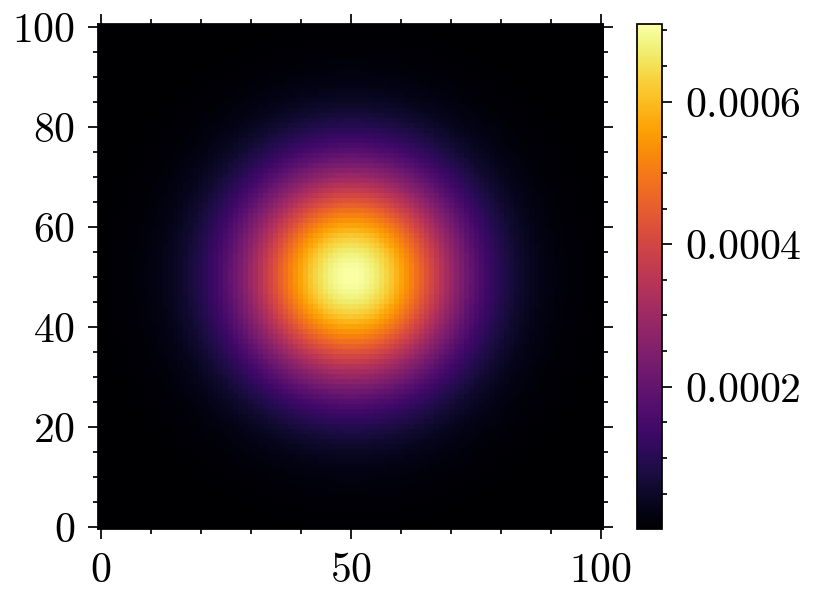

In [13]:
def gaussian_2d(shape, center=None, sigma=10):
    x = np.arange(0, shape[1])
    y = np.arange(0, shape[0])
    x, y = np.meshgrid(x, y)
    if center is None:
        center = (shape[1] // 2, shape[0] // 2)
    gauss = np.exp(-((x - center[0]) ** 2 + (y - center[1]) ** 2) / (2 * sigma**2))
    return gauss / gauss.sum()


# source_size = 81  # pixels
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

# sci_fits = [DynamicResolvedFit(file, source_size) for file in sci_files]
# sci_fits = [dorito.model_fits.ResolvedFit(file) for file in sci_files]
sci_fits = [dorito.model_fits.TransformedResolvedFit(file) for file in sci_files]
cal_fits = [amigo.model_fits.PointFit(file) for file in cal_files]

# I only want to use the calibrator in the same primary dither position
fits = sci_fits[0:1] + cal_fits[0:1]
# fits = sci_fits + cal_fits[0:1]

# building the model
init_dist = np.ones((source_size, source_size)) / (source_size**2)
init_dist = gaussian_2d(init_dist.shape, sigma=15)
plt.imshow(init_dist)
plt.colorbar()
plt.show()

abbs = np.load("files/abers.npy", allow_pickle=True).item()
state = load_dict(cache + "calibration.npy")
state["aberrations"]["F430M"] = abbs["01373_F430M"]

model = dorito.models.TransformedResolvedModel(
    # model = dorito.models.ResolvedAmigoModel(
    exposures=fits,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    basis=tukey_basis,
    state=state,
    # param_initers={"coeffs": np.array(new_coeffs)},
    # param_initers={"coeffs": tukey_basis.to_eigenbasis(init_dist)},
    param_initers={
        "coeffs": normalise_coeffs(
            tukey_basis,
            tukey_basis.to_eigenbasis(init_dist / init_dist.sum()),
            # tukey_basis.to_eigenbasis(np.log10(init_dist / init_dist.sum())),
        )
    },
    rotate=False,
    # param_initers={"distribution": init_dist},
    # param_initers={"coeffs": tukey_basis.to_eigenbasis(mask / mask.sum())},
    # param_initers={"coeffs": tukey_basis.to_eigenbasis(np.log10(mask / mask.sum()))},
)

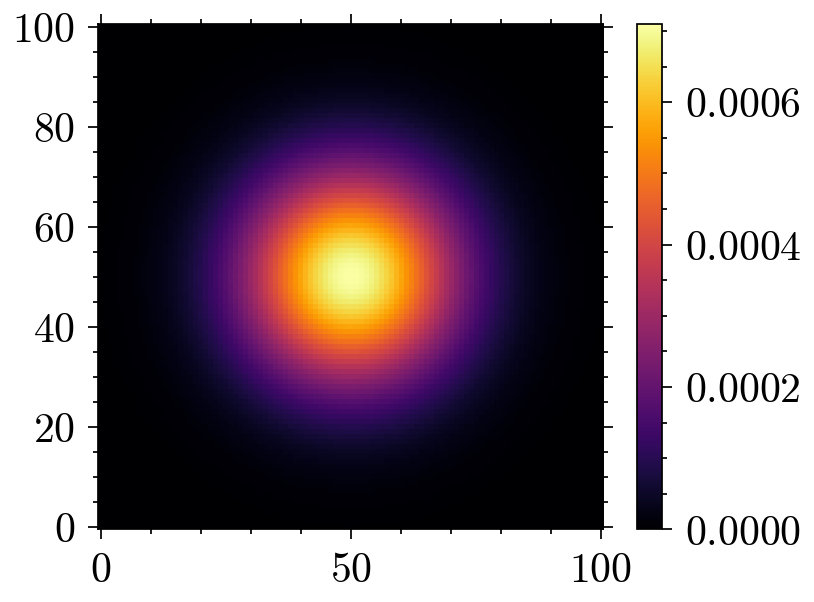

In [14]:
plt.imshow(model.get_distribution(sci_fits[0]))
plt.colorbar()
plt.show()

In [15]:
# for exp in fits:
#     exp.print_summary()
#     amigo.plotting.summarise_fit(model, exp, residuals=False)

## Optimisation Stage 1: Gradient Descent

In [16]:
pos_keys = []
spc_keys = []
for exp in fits:
    if not exp.calibrator:
        pos_keys.append(exp.map_param("positions"))
        spc_keys.append(exp.map_param("spectra"))


def loLU(x, lol=1e6):
    return np.log(1 + np.exp(lol * x))


def norm_fn(model_params, args):
    params = model_params.params
    # if "log_dist" in params.keys():
    #     for k, coeffs in params["log_dist"].items():
    #         # distribution = tukey_basis.from_eigenbasis(coeffs)
    #         # distribution = np.clip(distribution, 0)
    #         distribution = 10 ** tukey_basis.from_eigenbasis(coeffs)
    #         distribution /= distribution.sum()
    #         distribution = np.log10(distribution)
    #         coeffs = tukey_basis.to_eigenbasis(distribution)
    #         params["log_dist"][k] = coeffs

    # if "log_dist" in params.keys():
    #     for k, log_dist in params["log_dist"].items():
    #         distribution = 10**log_dist
    #         distribution /= distribution.sum()
    #         distribution = np.log10(distribution)
    #         params["log_dist"][k] = distribution

    if "log_dist" in params.keys():
        for k, coeffs in params["log_dist"].items():
            dist = tukey_basis.from_eigenbasis(coeffs)
            # dist = np.clip(dist, 0)
            # if dist.min() < 0:
            # dist += np.array([-dist.min(), 0]).max()
            dist = dist / dist.sum()
            coeffs = tukey_basis.to_eigenbasis(dist)
            params["log_dist"][k] = coeffs

    if "spectra" in params.keys():
        spectra = jtu.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


def loss_fn(model, exp, args={"reg_dict": {}}):
    # this is per exposure

    # regular likelihood term
    likelihood = -np.nanmean(exp.mv_zscore(model))

    # prior on the sum
    dist = model(exp)
    total_sum = dist.sum()
    prior = 0
    prior -= jax.scipy.stats.norm.logpdf(total_sum, loc=1.0, scale=0.00001)
    prior += loLU(-dist).sum()
    prior += (
        dorito.stats.apply_regularisers(model, exp, args) if not exp.calibrator else 0.0
    )
    # prior = 1e6 * jax.nn.relu(-dist).sum()
    return likelihood + prior, ()


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample

In [ ]:
n_epoch = 2500

config = {
    # "positions": sgd(4e-2, 0),
    # "fluxes": sgd(3e-1, 0),
    # "aberrations": sgd(1e0, 4),
    # "aberrations": sgd(3e-2, 4),
    "spectra": sgd(1e-1, 500),
    "positions": sgd(5e-1, 5, (50, 0.0)),
    "fluxes": sgd(2e-2, 0),
    # "log_dist": adam(1e0, 10.0),
    # "log_dist": sgd(2e-4, 15),
    # "log_dist": warmup_adam(1e-1, 100),
    # "log_dist": adam(1e-3, 15, (400, 1e1)),
    "log_dist": adam(5e-5, 15),
    # "log_dist": adam(2e-4, 15),
    # "log_dist": adam(5e-2, 10),
}


def grad_fn(model, grads, args):
    # Nuke the position gradients for the science exposures
    if "positions" in config.keys():
        grads = grads.multiply(pos_keys, 0.3)

    # Reduce spectra gradients for the science exposures
    if "spectra" in config.keys():
        grads = grads.multiply(spc_keys, 1e-2)
    return grads, args


args = {
    "reg_dict": {
        # "TSV": (1e6, dorito.stats.TSV),
        # "ME": (mes[int(batch_idx)], dorito.stats.ME),
    }
}

trainer = amigo.fitting.Trainer(
    loss_fn=loss_fn,
    norm_fn=norm_fn,
    # grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)
print("Populating fishers...")
trainer = trainer.populate_fishers(
    # model.set("detector.ramp.bleed", False).set("params", params),
    model,
    fits,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys()],  # if p not in ["log_distribution"]],
)

# print("Updating fishers...")
# trainer = trainer.update_fishers(
#     model,
#     fits,
#     parameters=["log_dist"],
#     recalculate=False,
#     overwrite=True,
#     verbose=True,
#     save=True,
#     batch_size=2,
# )

print("Number of exposures: ", len(fits))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=fits[0:1],  # Just the science
    args=args,
    # batches=fits[-1:],  # Just the calibrator
    # batches=fits,
)

Populating fishers...
KeyError: log_dist not in hessians for 01373_017_02_04_1, skipped
KeyError: log_dist not in hessians for 01373_023_02_03_1, skipped
Number of exposures:  2


  0%|          | 0/2500 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 90,425.96
Estimated run time: 0:19:29


KeyboardInterrupt: 

0.9999999999999997 -2.5342949639064197e-17 0.0018334537561330187 -1.38225191414239e-14


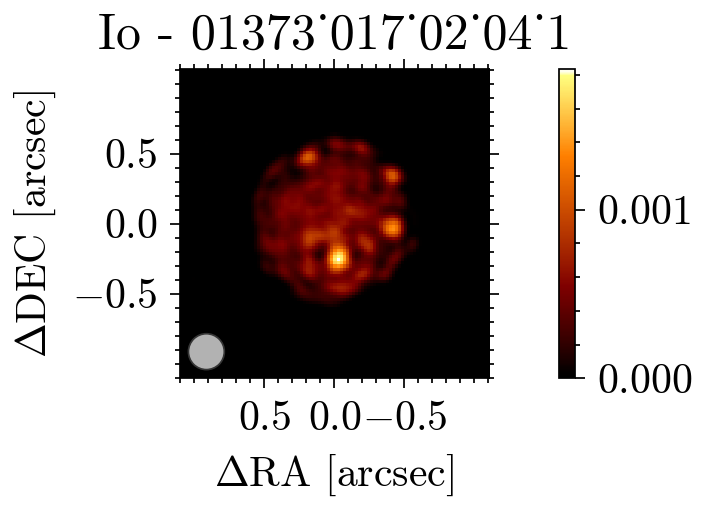

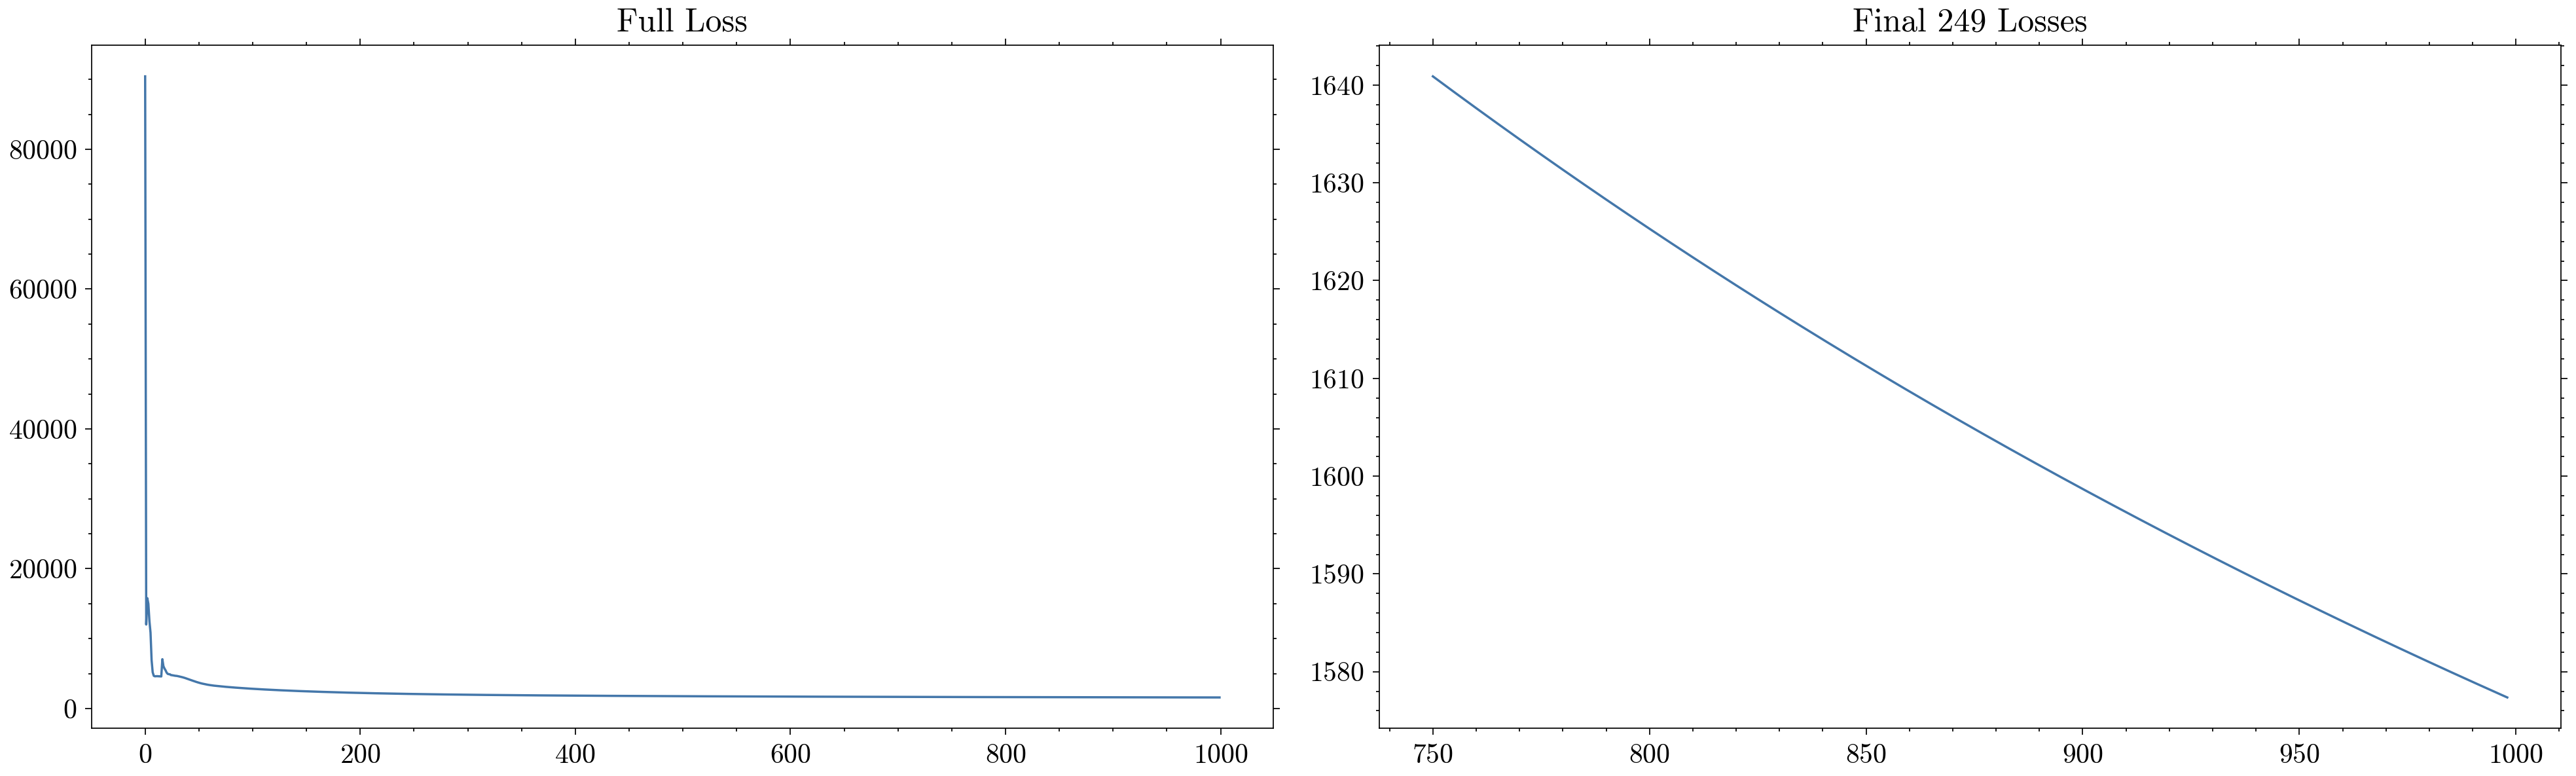

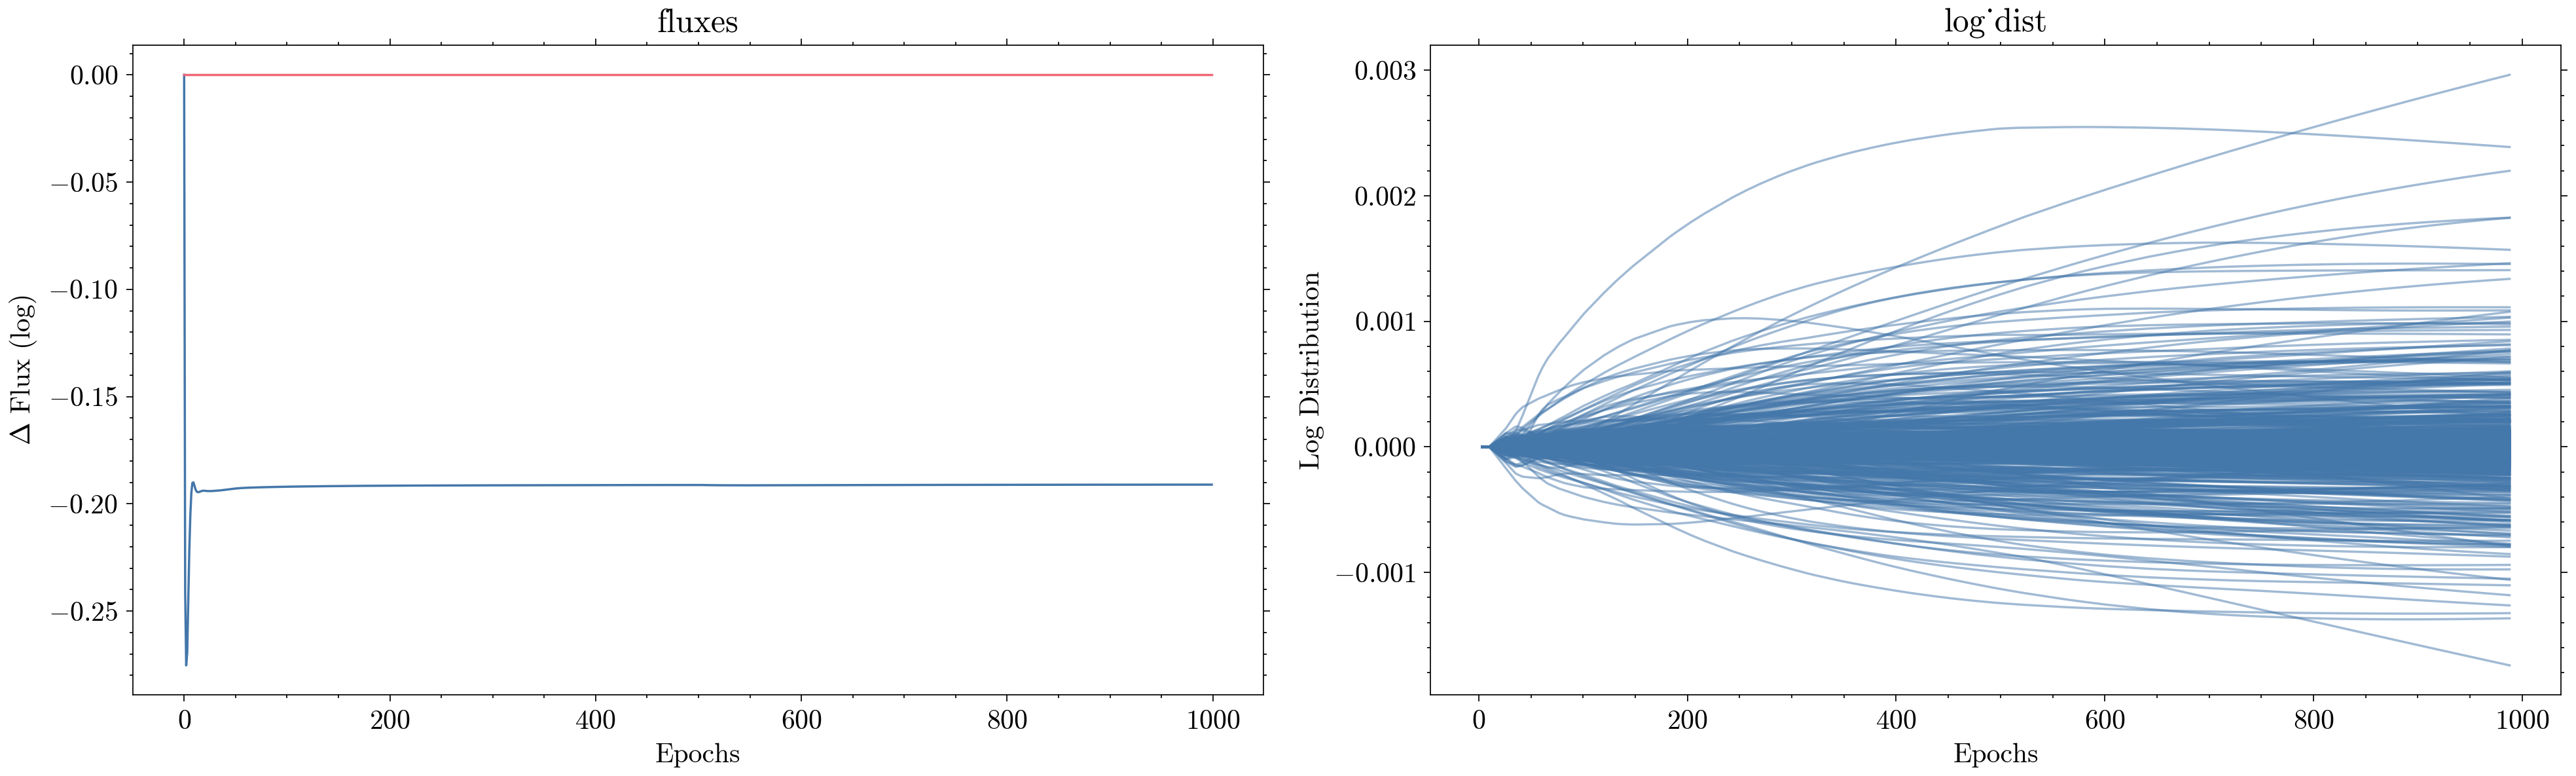

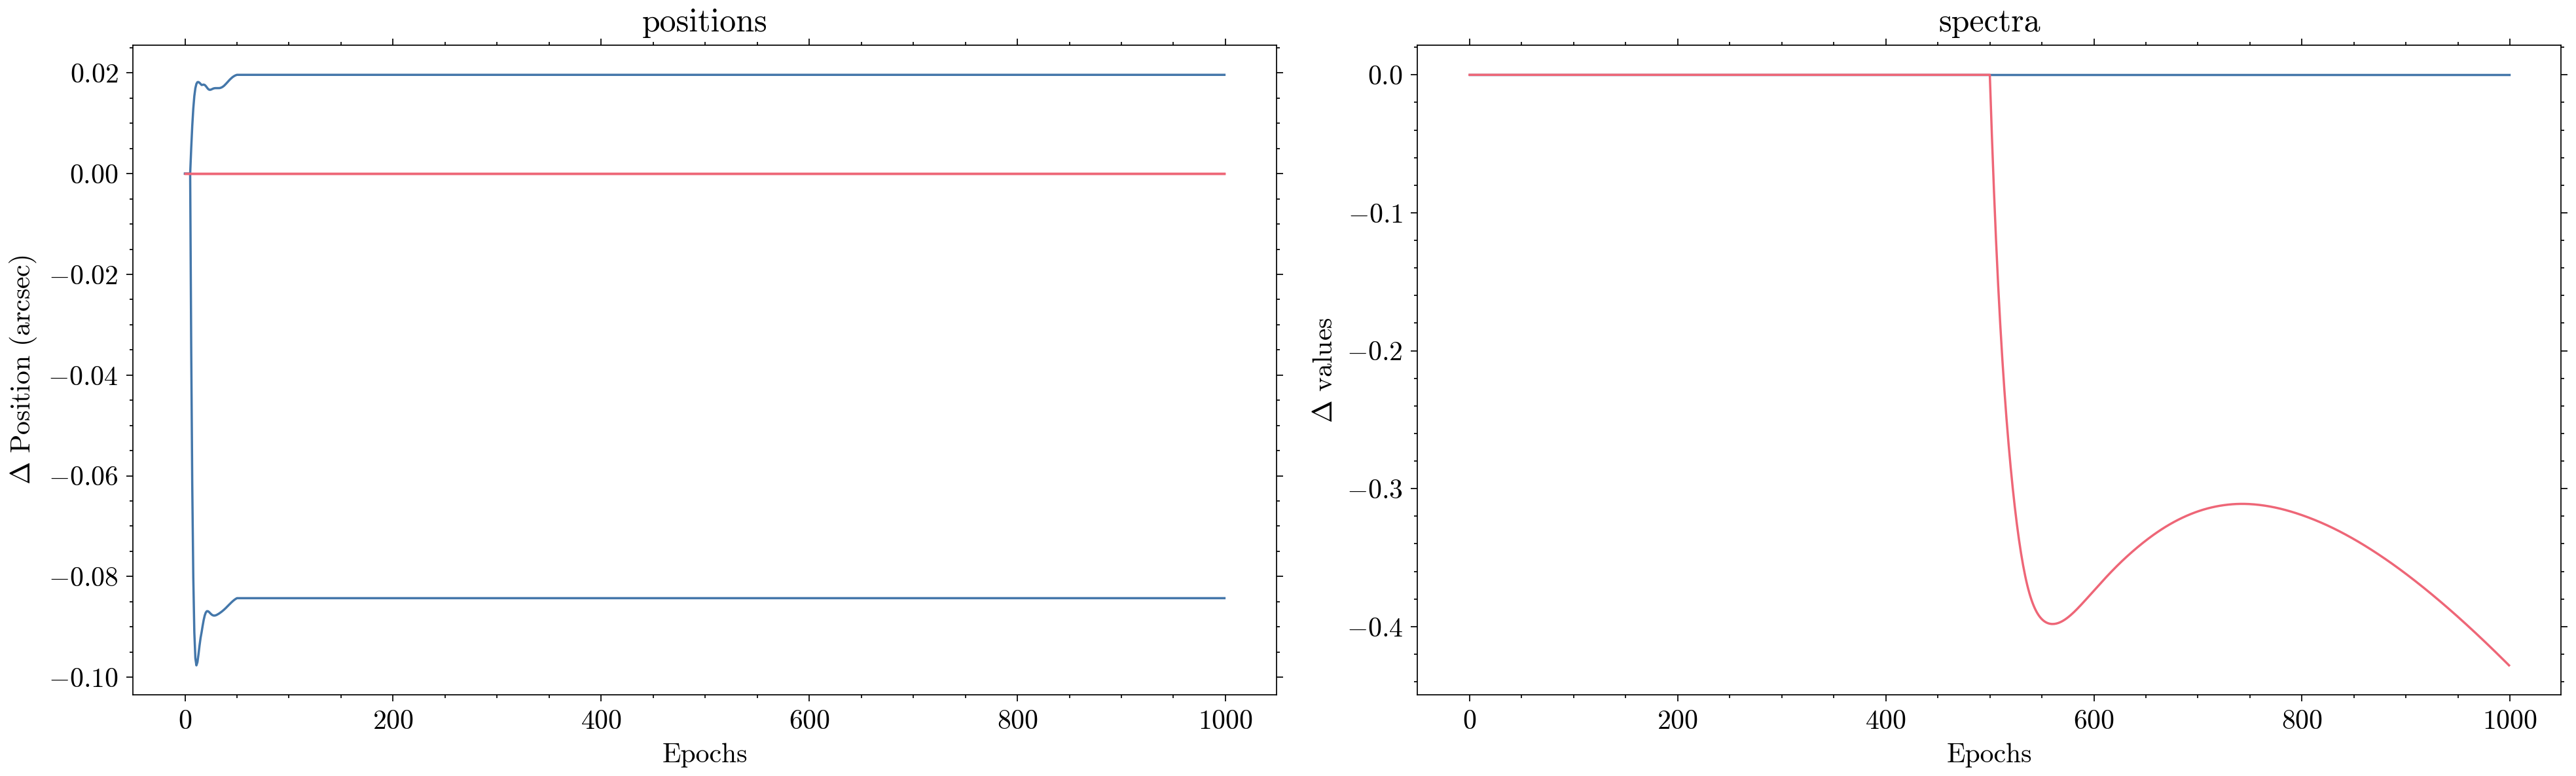

File 01373_017_02_04_1
Star IO
Filter F430M
nints 100
ngroups 18



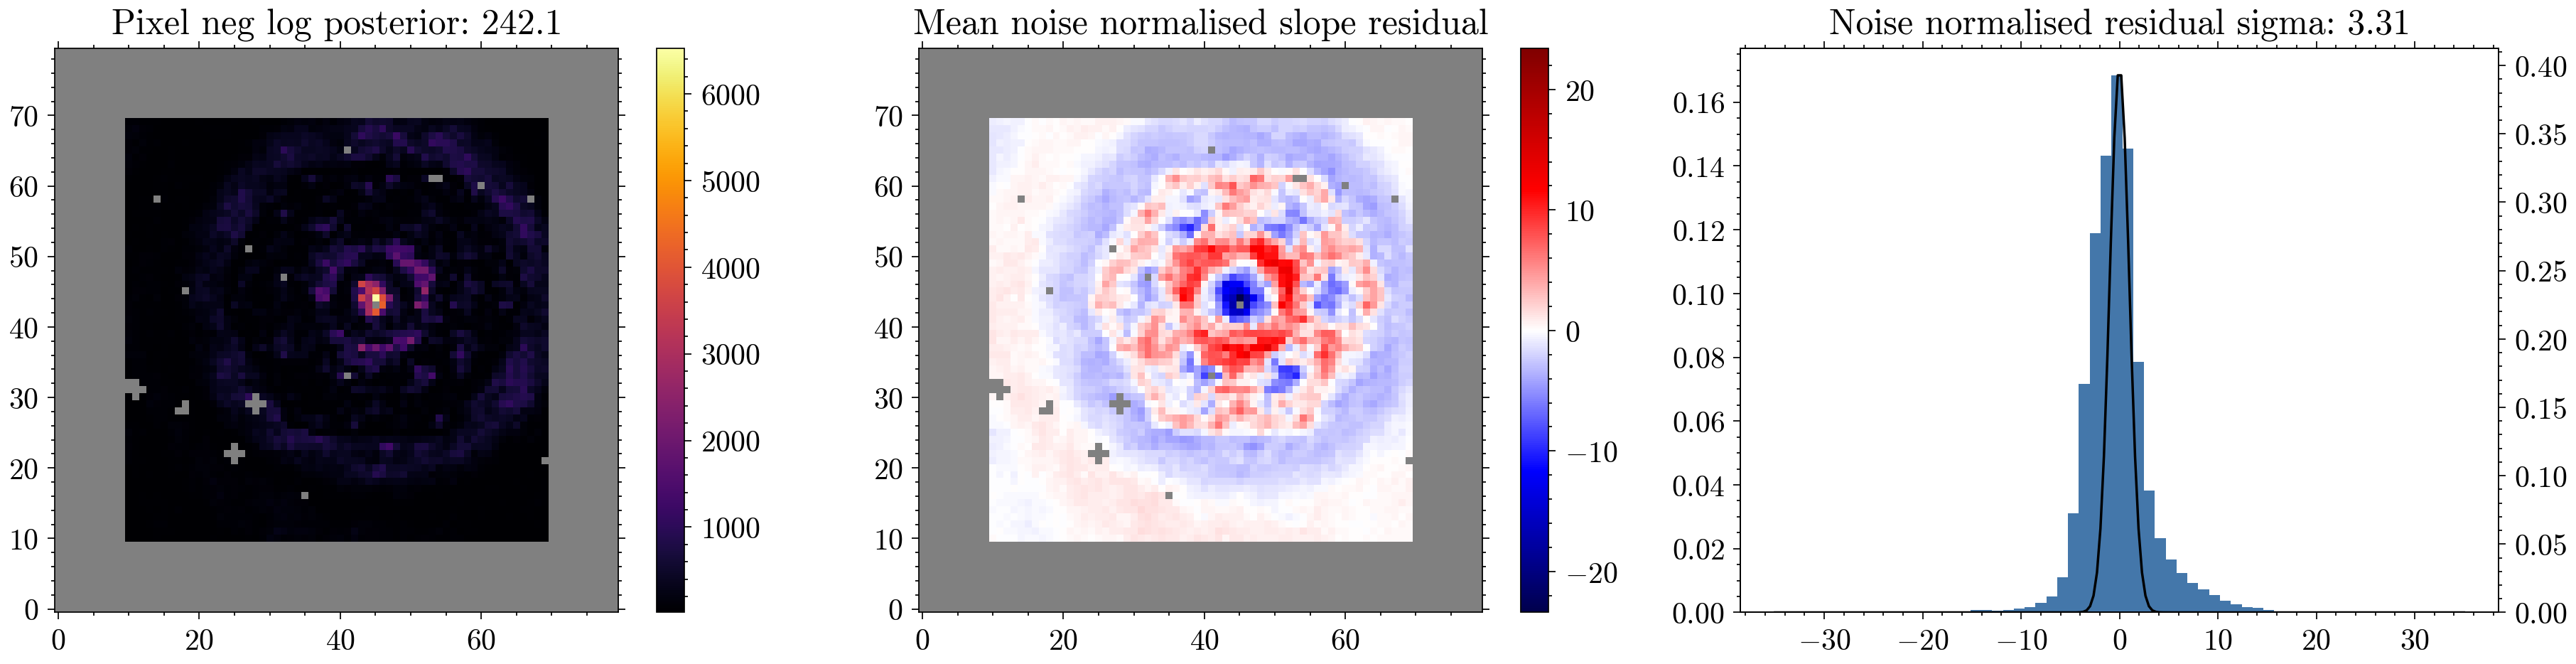

File 01373_023_02_03_1
Star HD 2236
Filter F430M
nints 8
ngroups 12



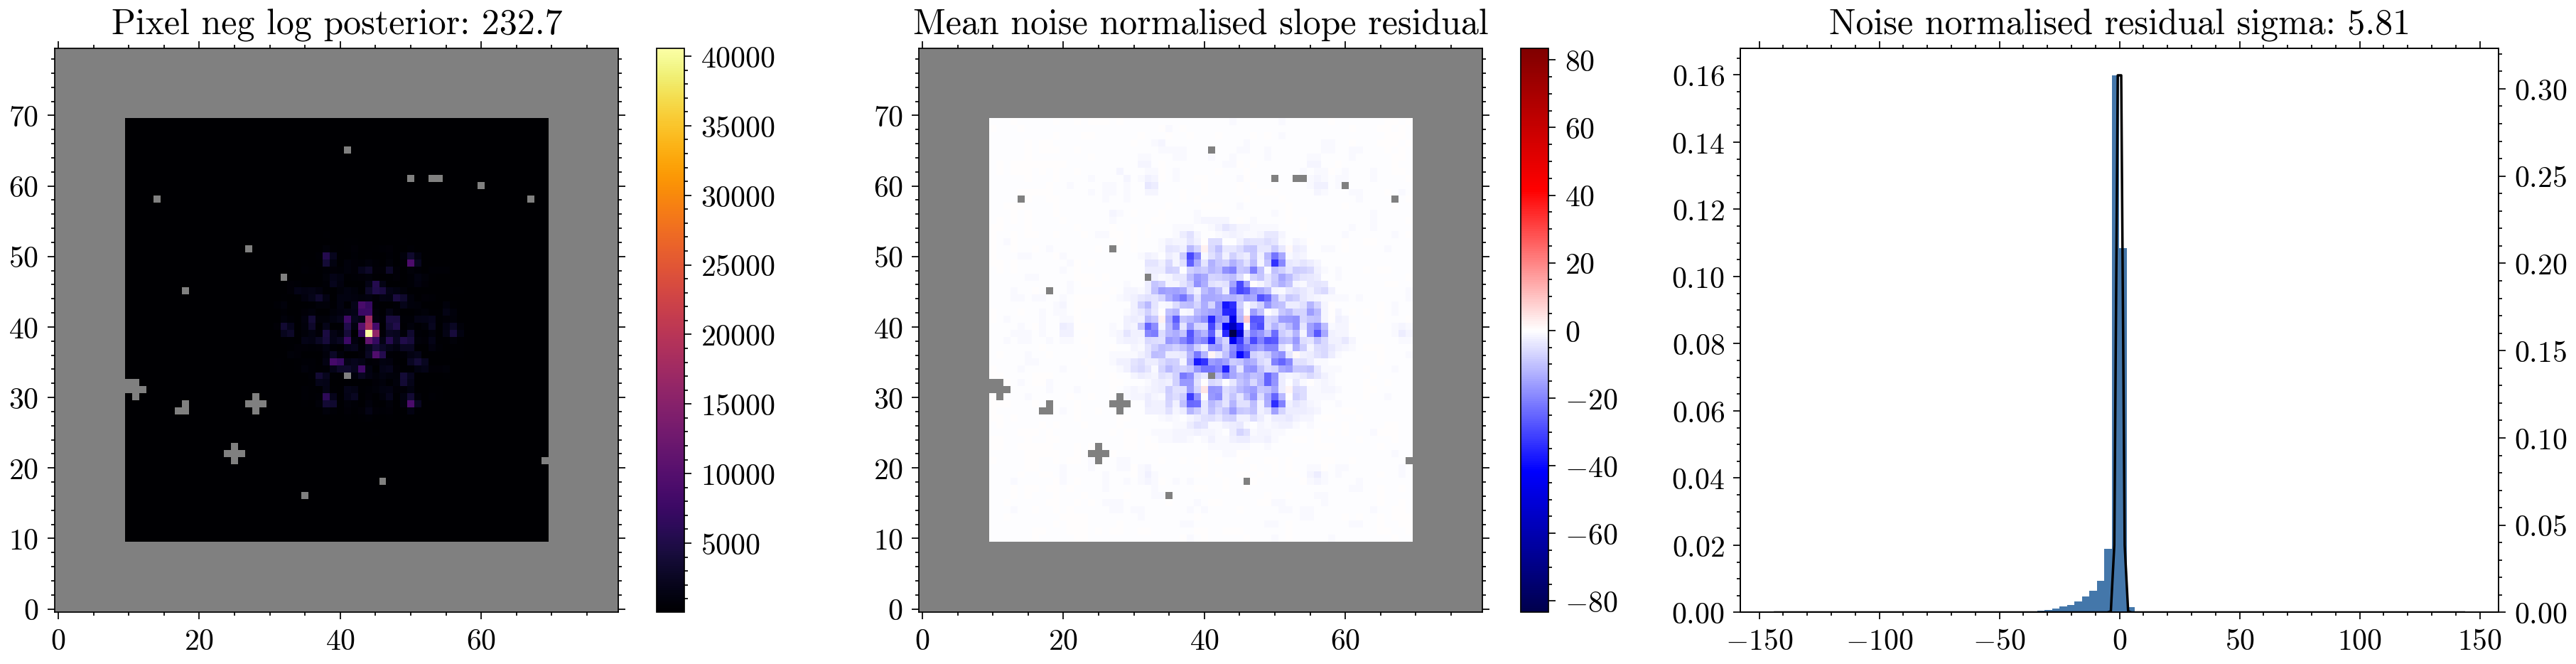

In [ ]:
from dLux import utils as dlu

optics_diameter = 6.603464  # JWST aperture diameter in meters
wavel = 4.3e-6

for exp in fits:

    if exp.calibrator:
        continue
    dist = result.model(exp)
    fig, ax = plt.subplots(figsize=(6, 2.3))
    print(dist.sum(), dist.min(), dist.max(), dist.min() / dist.max())
    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="afmhot_u",
        # norm=mpl.colors.CenteredNorm(),
        # roll_angle_degrees=-exp.parang,
        # norm=mpl.colors.LogNorm(vmin=1e-5),
        # norm=None,
        norm=mpl.colors.PowerNorm(1, vmin=0),
        diff_lim=dlu.rad2arcsec(wavel / optics_diameter),
        # scale=1.5,
    )

    fig.colorbar(c0)

    ax.set(title=f"Io - {exp.key}")  #   xticks=ticks, yticks=ticks)

    plt.tight_layout()
    plt.show()

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

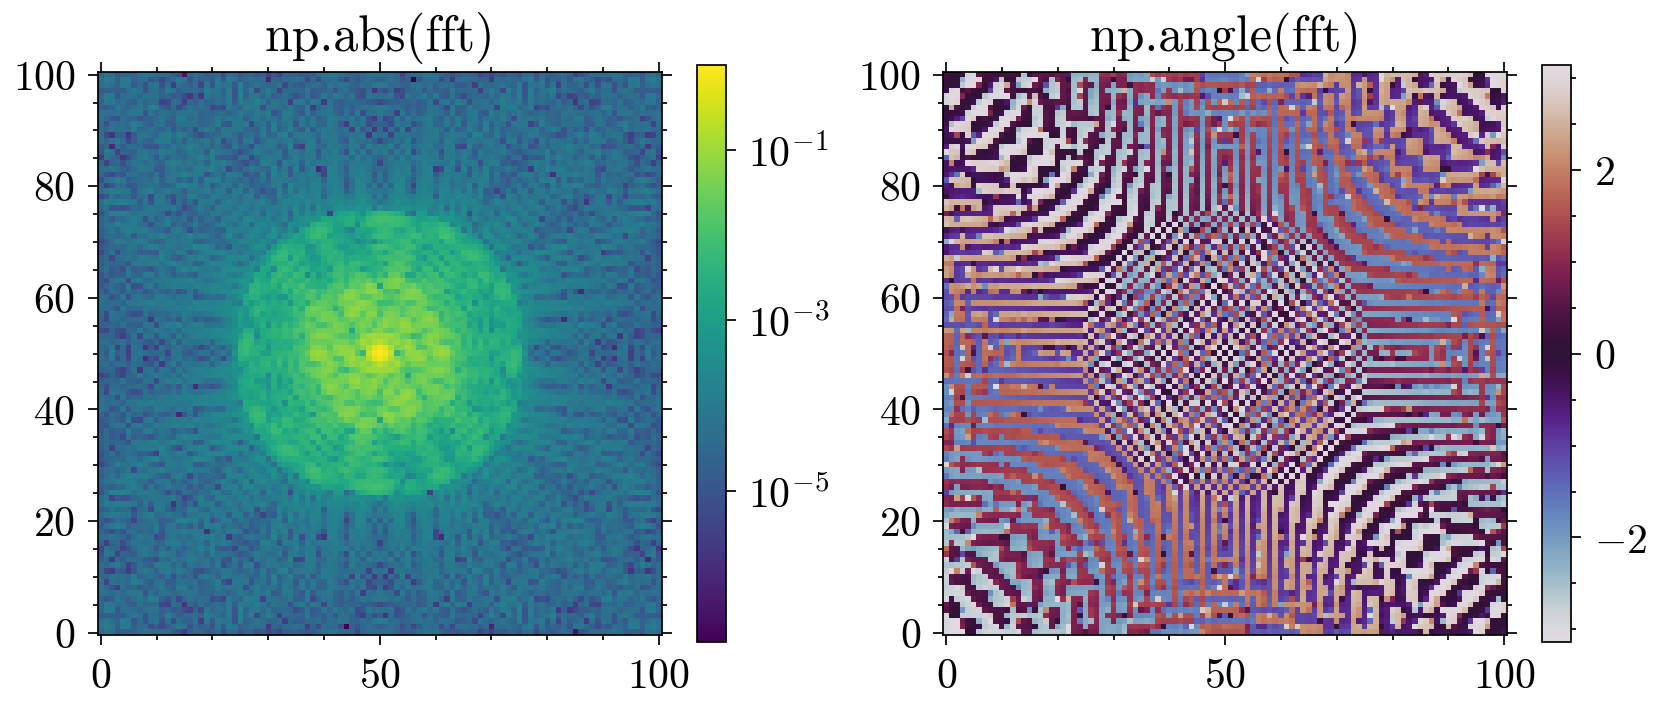

In [ ]:
fft = np.fft.fftshift(np.fft.fft2(dist))

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.title("np.abs(fft)")
plt.imshow(np.abs(fft), cmap="viridis", norm=mpl.colors.LogNorm(vmin=None))
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("np.angle(fft)")
plt.imshow(np.angle(fft), vmin=-np.pi, vmax=np.pi, cmap="twilight")
plt.colorbar()
plt.show()

## Optimisation Stage 2: BFGS

In [ ]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args
    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return loss_fn(model, exp)[0]


def bfgs_solve(model, exposures, params, rtol=1e-6, atol=1e-6, max_steps=2048):

    args_out = {}
    sols_out = {}

    for exp in exposures:
        print(f"Solving for {exp.key}...")
        opt_params = {}
        fishers = {}
        shapes = {}

        for param in params:
            # print()
            key = exp.map_param(param)
            try:
                shapes[key] = model.get(key).shape
            except AttributeError:
                print(model.get(key))
                raise AttributeError(
                    f"Parameter {key} not found in final model. Check the parameter name."
                )
            opt_params[key] = model.get(key).flatten()

            new_key = ".".join([exp.key, param])

            if new_key in trainer.fishers.keys():
                fishers[key] = trainer.fishers[f"{exp.key}.{param}"]
            else:
                print(f"Did not find {key} in fishers, setting to one...")
                fishers[key] = np.eye(opt_params[key].size)
                continue

        shapes = ModelParams(shapes)
        model_params = ModelParams(opt_params)
        initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
        proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
        proj_mats = jtu.map(
            lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats
        )
        args = (model, exp, model_params, proj_mats, shapes)
        args_out[exp.key] = args

        print("Initial loss:", fun(initial_params, args))
        solver = optx.BFGS(rtol=rtol, atol=atol)
        sol = optx.minimise(
            fun,
            solver,
            initial_params,
            args,
            throw=False,
            max_steps=max_steps,
        )
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    return sols_out, args_out

In [ ]:
final_model = result.model

# cal_params = ["positions", "fluxes", "aberrations", "spectra"]
# cal_sols_out, cal_args_out = bfgs_solve(final_model, cal_fits, cal_params)

# for key, args in cal_args_out.items():
#     proj_mats = args[3]
#     proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, cal_sols_out[key].value)
#     model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
#     model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
#     final_model = model_params.inject(final_model)

In [ ]:
sci_params = ["fluxes", "log_dist", "spectra"]
sci_sols_out, sci_args_out = bfgs_solve(
    final_model, sci_fits[0:1], sci_params, rtol=1e-10, atol=1e-10
)

spectra = {}
for key, args in sci_args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sci_sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(
    lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
)
final_model.spectra[exp.get_key("spectra")] = spectra[exp.get_key("spectra")]

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

Solving for 01373_017_02_04_1...
Did not find log_dist.F430M in fishers, setting to one...
Initial loss: 1566.379436480096
Final loss: 1566.377393474842
13 8




F430M Science IO 18
Loss: 1576.971


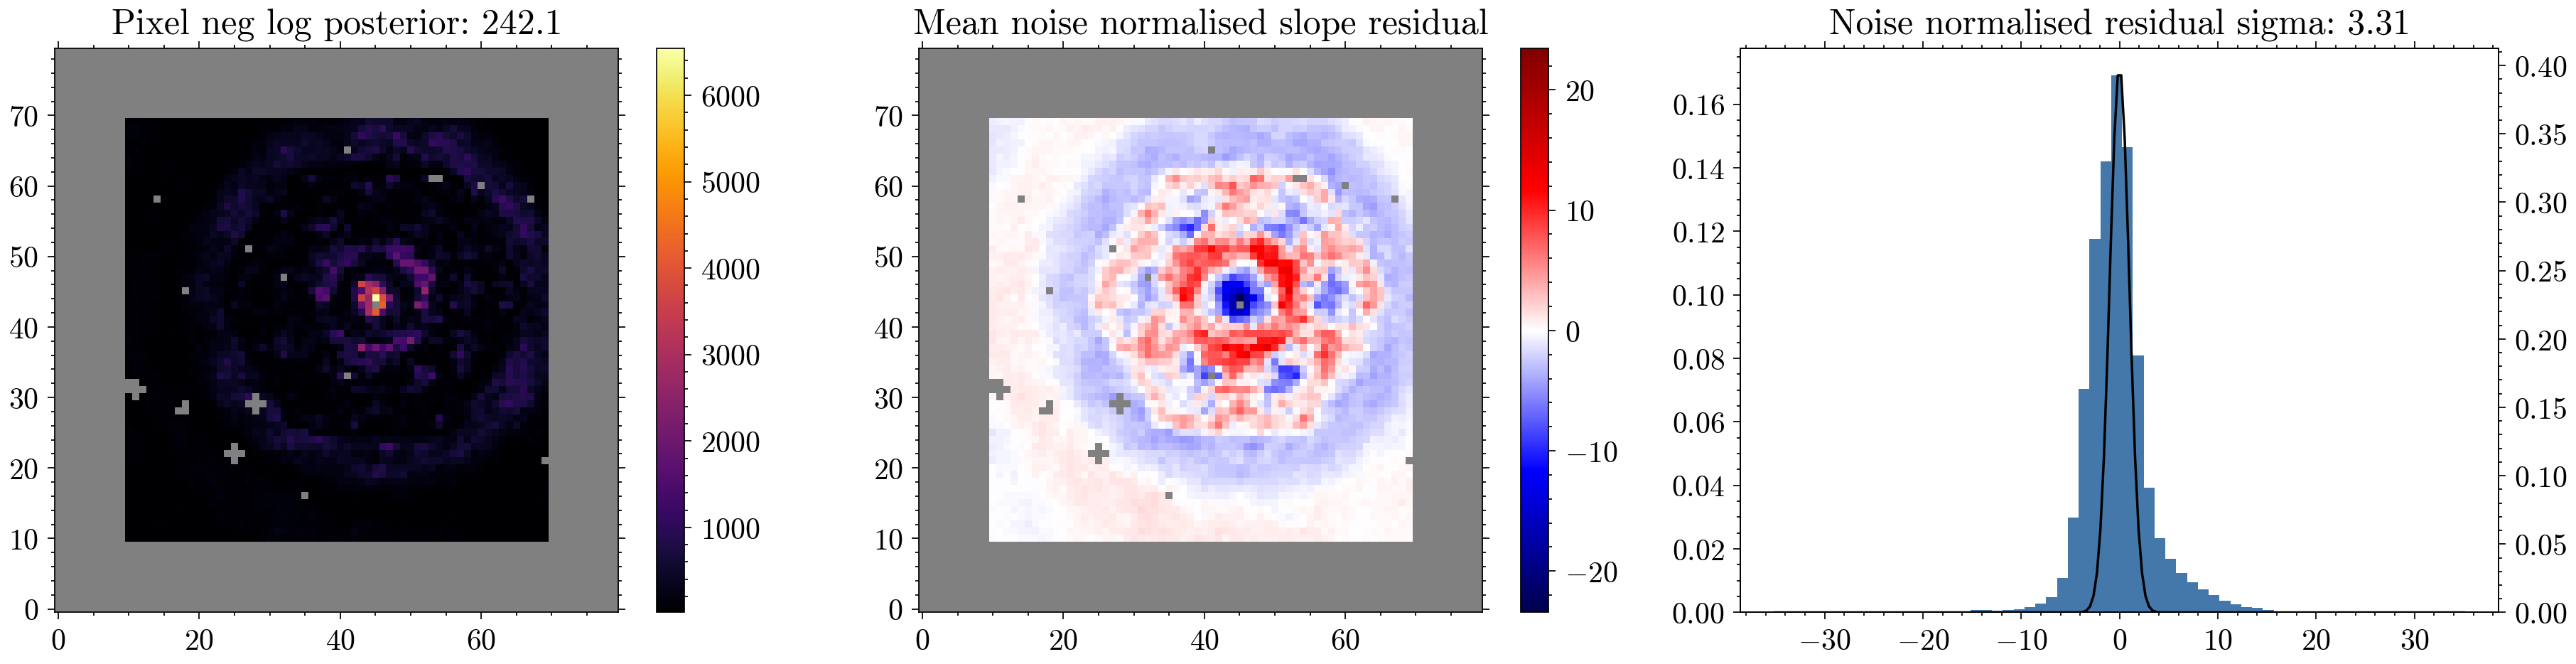

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in sci_fits[0:1]:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            print(f"Loss: {trainer.loss_fn(final_model, exp)[0]:.3f}")
            amigo.plotting.summarise_fit(final_model, exp)

## Results

In [ ]:
import planetmapper
import scipy

features = {
    "seth": (132, -5.3),  # long [deg], lat [deg]
    "P197": (108.8, -47.3),
    "masubi": (52.6, -45),
    "leizi": (44.93, 13.48),
    # "leizi": (-315.074, 13.48),
    "amirani": (115.2, 24.0),
    # "subobs": (--107.57361768, 2.60587485),
}
# https://iopscience.iop.org/article/10.3847/PSJ/ad4346/pdf


def plot_io_with_ephemeris(
    ax,
    array,
    exp,
    data_dir,
    pixel_scale,
    roll_angle_degrees=0.00,
    legend=False,
    points=None,
    **kwargs
):

    body = planetmapper.Observation(data_dir + exp.filename + "_uncal.fits")
    if points is not None:
        body.coordinates_of_interest_lonlat = points

    def coordinate_func(ra, dec):
        x, y = body.radec2angular(ra, dec)
        return -x, y

    body.plot_wireframe_custom(
        # body.plot_wireframe_angular(
        ax,
        coordinate_func=coordinate_func,
        # aspect_adjustable="box",
        add_title=False,
        label_poles=True,
        indicate_equator=True,
        indicate_prime_meridian=True,
        grid_interval=30,
        grid_lat_limit=75,
        formatting={
            # "limb": {
            #     "linestyle": "--",
            #     "linewidth": 0.8,
            #     "alpha": 0.8,
            #     "color": "white",
            # },
            "grid": {
                "linestyle": "--",
                "linewidth": 0.5,
                "alpha": 0.3,
                "color": "k",
            },
            "equator": {
                "color": "r",
                "linewidth": 1,
                "color": "r",
                "label": "equator",
                # "alpha": 0.0,
            },
            "terminator": {
                "linewidth": 1,
                "linestyle": "-",
                "color": "aqua",
                "alpha": 0.0,
                "label": "terminator",
            },
            "coordinate_of_interest_lonlat": {
                "color": "gold",
                "marker": "^",
                "facecolors": "none",
                # "markeredgecolor": "red",
                "s": 10,
                "label": "volcano",
            },
            "limb_illuminated": {"color": "b", "alpha": 0.0},
        },
    )

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper left",
        )

    im = plot_result(
        ax,
        array,
        pixel_scale=pixel_scale,
        roll_angle_degrees=roll_angle_degrees,
        show_diff_lim=True,
        **kwargs,
    )

    return im


def plot_diffraction_limit(model, ax=None, OOP=False):
    effective_wl = np.dot(
        model.source_spectrum.wavelengths, model.source_spectrum.weights
    )
    diff_lim = dlu.rad2arcsec(effective_wl / model.optics.diameter)
    scale_length = diff_lim

    scale_bar_x = -0.7
    scale_bar_y = scale_bar_x
    fontdict = {
        "fontstyle": "normal",
        "color": "hotpink",
        "weight": "demi",
        "size": 7,
    }

    if OOP and ax is not None:
        ax.plot(
            [scale_bar_x, scale_bar_x + scale_length],
            [scale_bar_y, scale_bar_y],
            color="hotpink",
            linewidth=2,
        )
        ax.text(
            scale_bar_x + scale_length / 2 - 0.075,
            scale_bar_y + 0.03,
            r"$\lambda / D$",
            **fontdict,
        )
        return ax

    else:
        plt.plot(
            [scale_bar_x, scale_bar_x + scale_length],
            [scale_bar_y, scale_bar_y],
            color="hotpink",
            linewidth=2,
        )
        plt.text(
            scale_bar_x + scale_length / 2 - 0.046,
            scale_bar_y + 0.02,
            r"$\lambda / D$",
            **fontdict,
        )


def compute_com_physical(array, pixel_scale):
    """
    Compute the center of mass of a 2D array, assuming the center of the array is at (0, 0).

    Parameters:
    - array: 2D numpy array representing the mass distribution.
    - pixel_scale: The physical scale of each pixel (e.g., in units per pixel).

    Returns:
    - com_physical: The center of mass in physical coordinates, assuming (0, 0) at the center of the array.
    """
    # Compute the center of mass in pixel indices
    com_index = np.array(scipy.ndimage.center_of_mass(numpy.array(array)))

    # Calculate the center of the array in pixel indices
    array_center = np.array(array.shape) / 2 - 0.5  # (rows/2 - 0.5, cols/2 - 0.5)

    # Convert to physical coordinates
    com_physical = (com_index - array_center) * pixel_scale

    return np.array(
        [-com_physical[1], com_physical[0]]
    )  # Return (x, y) in physical coordinates

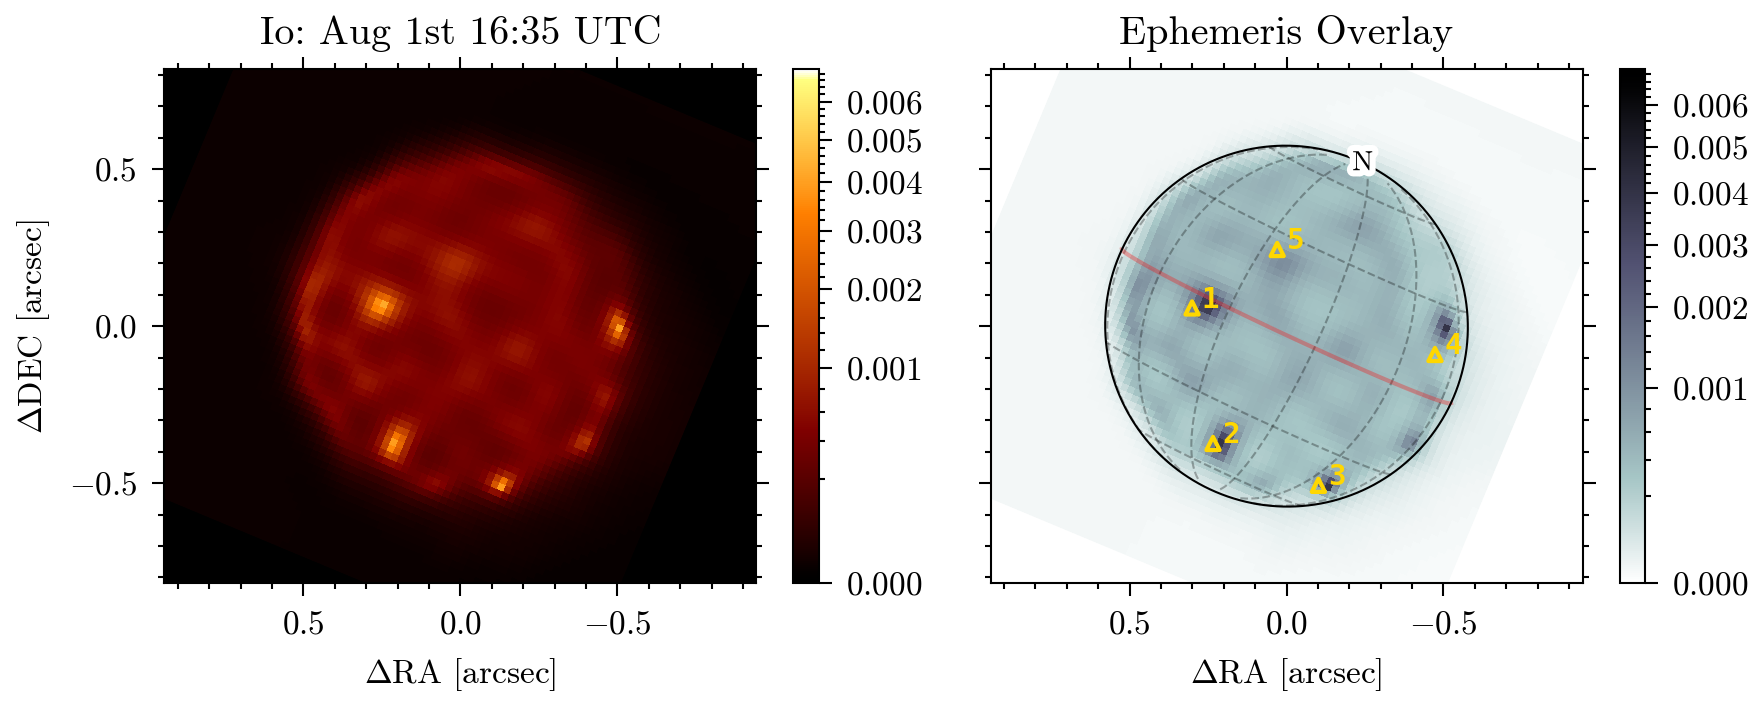

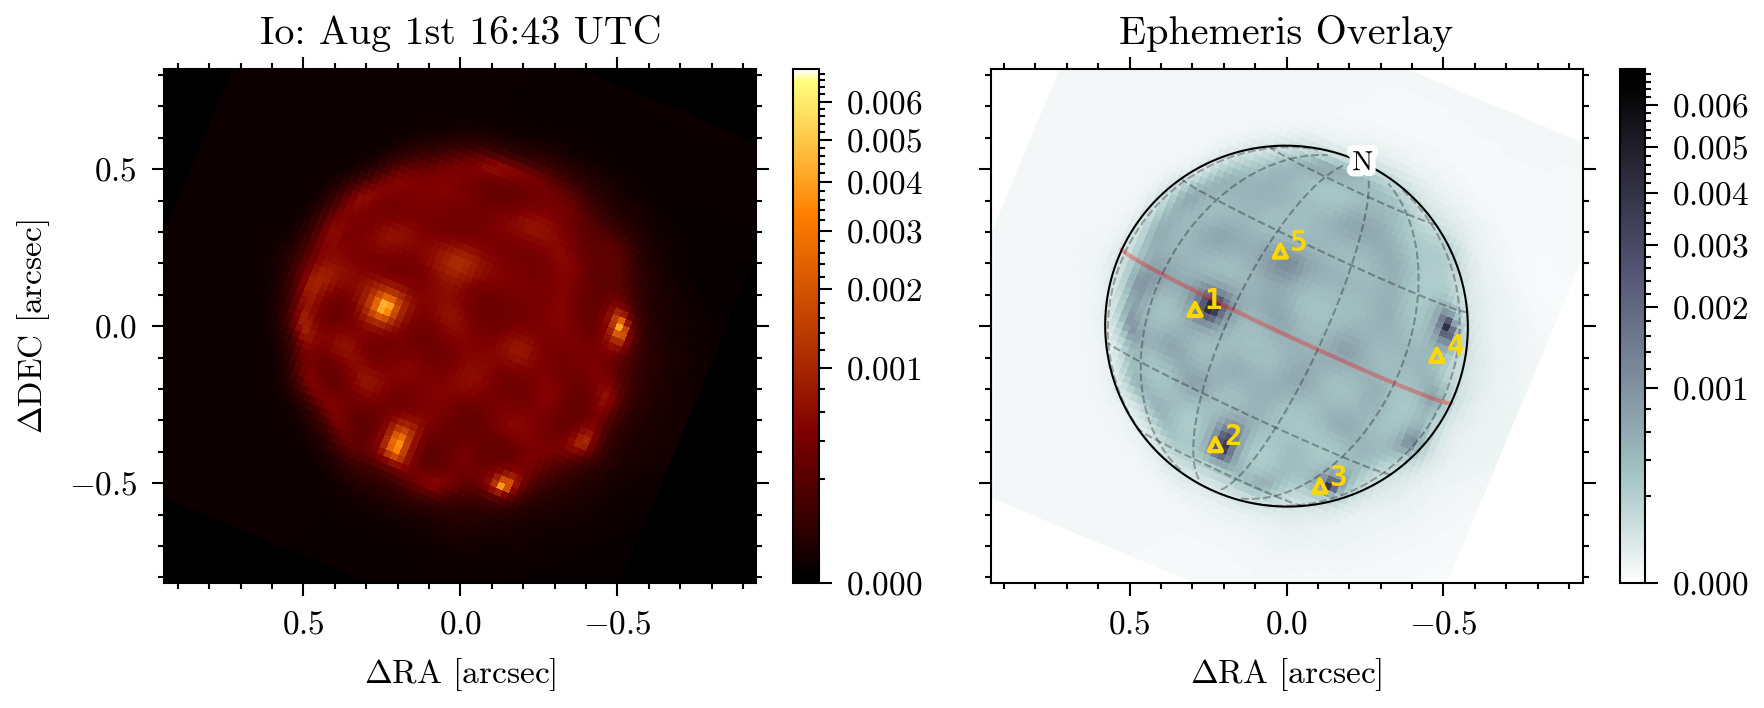

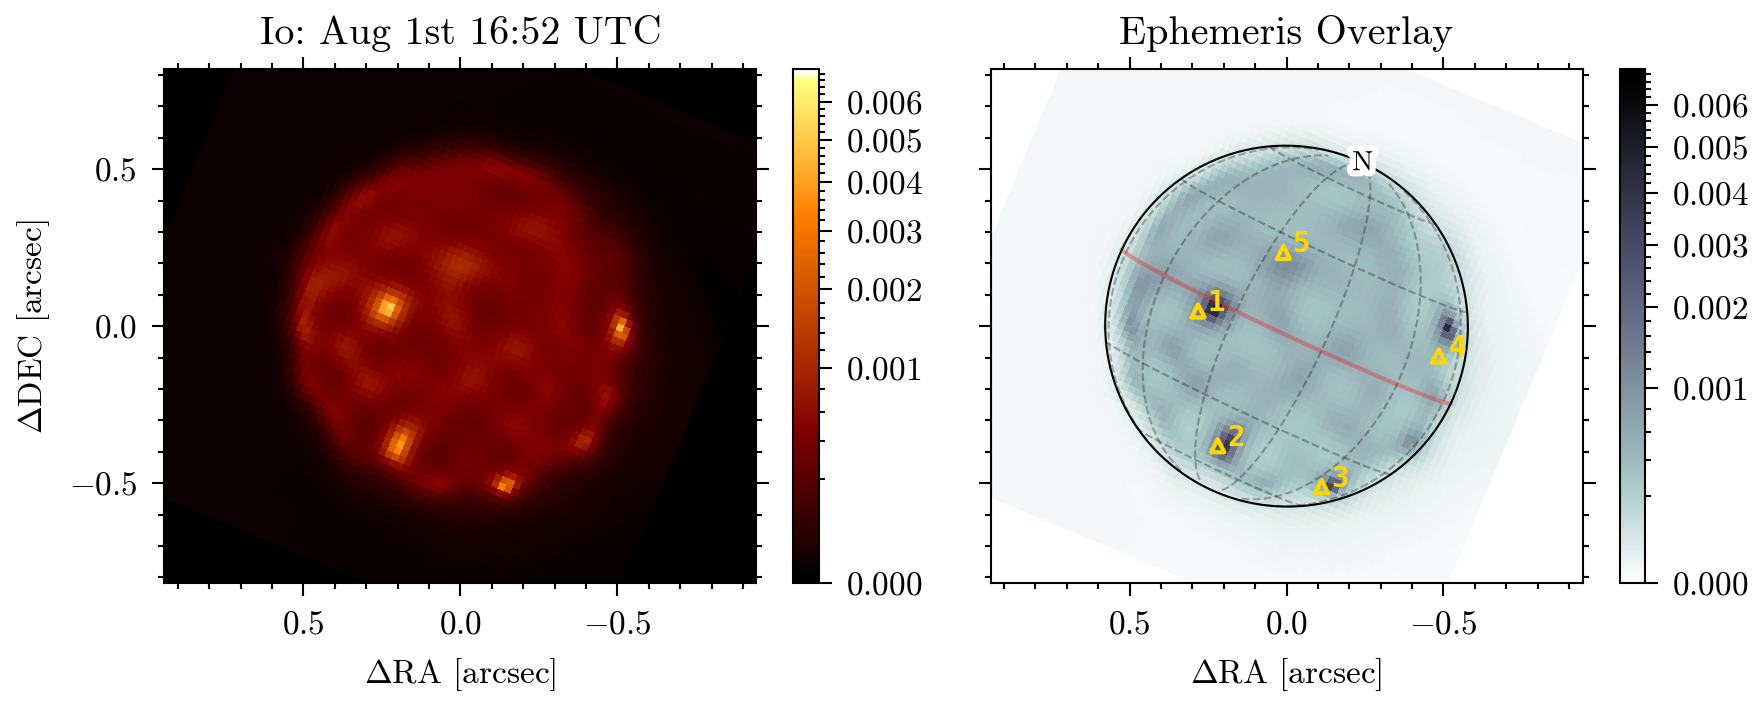

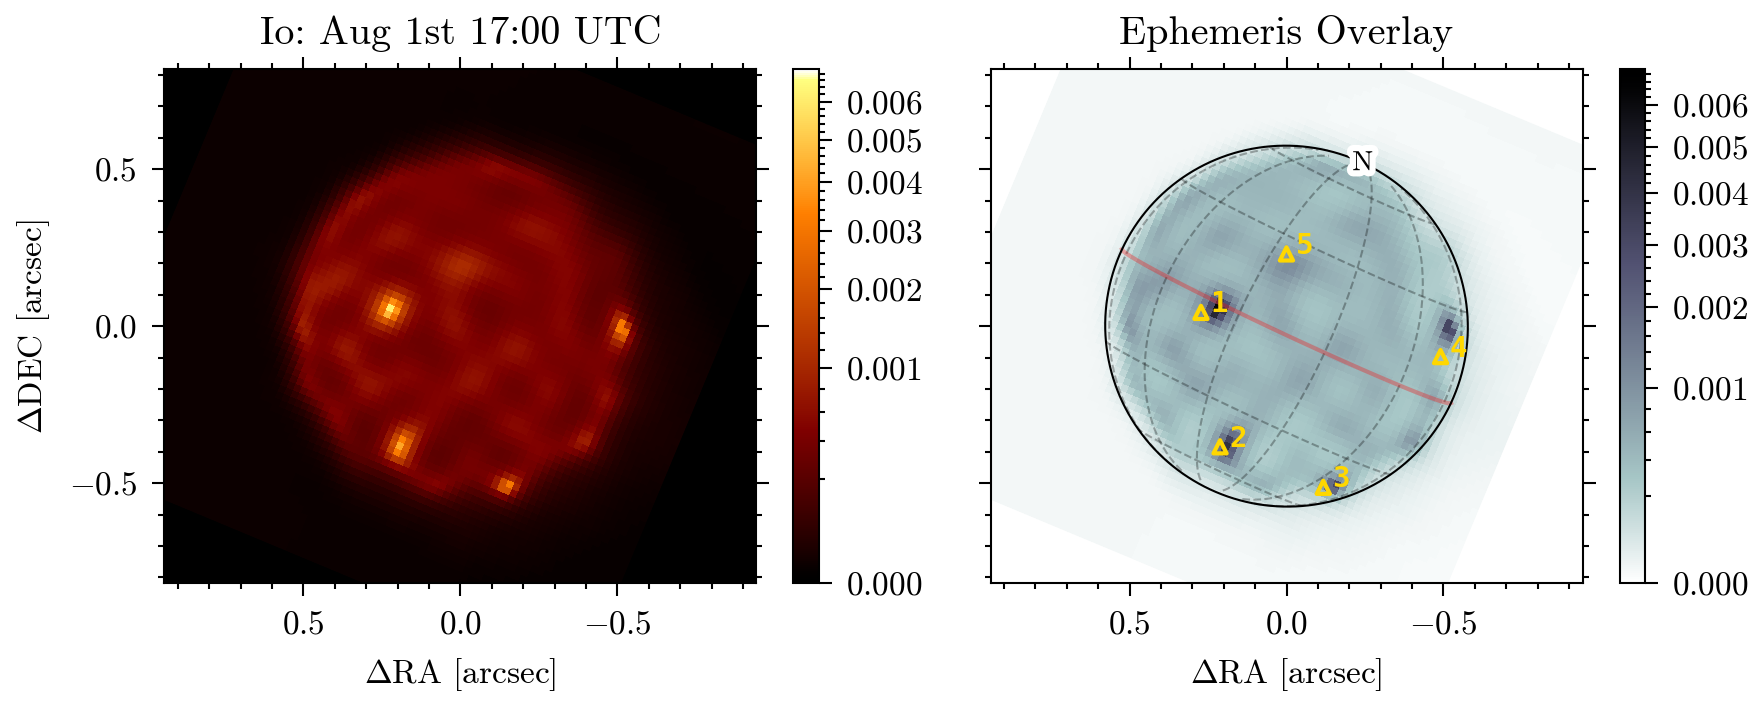

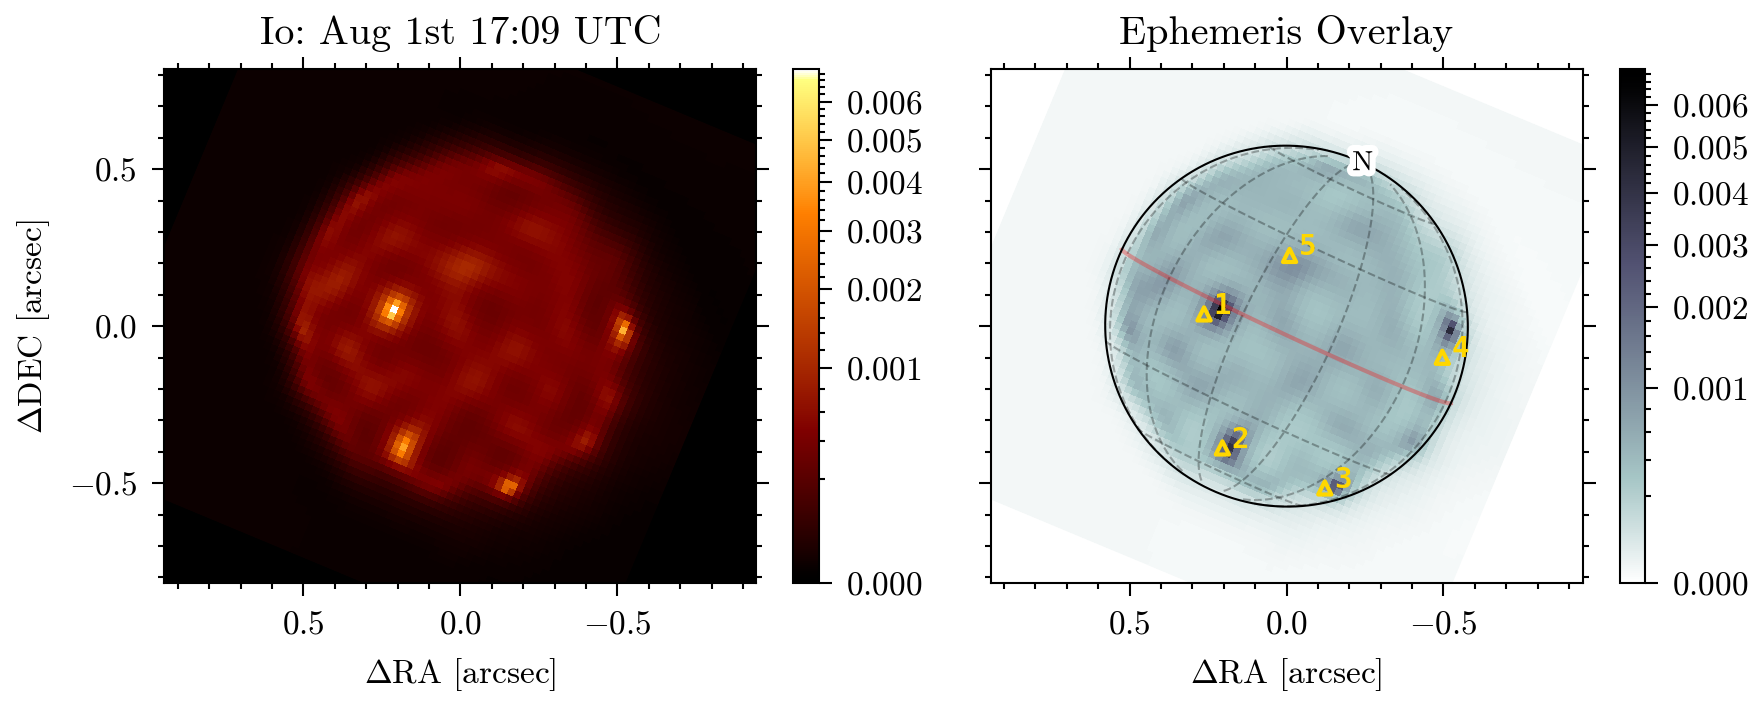

In [ ]:
# from planetmapper.kernel_downloader import download_urls

# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/")
# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/")
# download_urls(
#     "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp"
# )
# download_urls("https://naif.jpl.nasa.gov/pub/naif/JWST/kernels/spk/")


result_model = result.model


io_peak_flux = np.array([result_model.get_distribution(exp) for exp in sci_fits]).max()
clip_value = 0.001

save_dir = "gifs/spinning_io/"
for exp, file in zip(sci_fits, sci_files):

    dist = result_model.get_distribution(exp)

    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)
    c0 = plot_result(
        ax[0],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.45,
        roll_angle_degrees=-exp.parang,
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        ax[1],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-exp.parang,
        scale=source_size / 75.0,
        axis_labels={
            "xlabel": r"$\Delta$RA [arcsec]",
            "ylabel": "",
        },
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    eps = 3e-2
    for i, (x, y) in enumerate(coords):  # i should now correctly track the index
        ax[1].text(
            x - eps,
            y,
            f"{i+1}",
            fontsize=7,
            c="gold",
            fontfamily="monospace",
            fontweight="bold",
        )  # Use i in the label

    fig.colorbar(c0)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    ax[0].set_title(f"Io: Aug 1st {time.ymdhms[3]:02}:{time.ymdhms[4]:02} UTC")
    ax[1].set_title(f"Ephemeris Overlay")

    plt.tight_layout()
    fig.colorbar(c1, ax=ax[1])
    plt.savefig(output_path + f"{time.isot}.png", dpi=300)
    # plt.close()
    plt.show()

dorito.plotting.create_gif_from_dir(output_path, "io.gif", duration=0.5)

In [ ]:
dorito.plotting.create_gif_from_dir(output_path, "io.gif", duration=200, loop=0)

In [ ]:
def get_exposing(files, eps=1e0, samples=1e4):

    starts = []
    ends = []
    for file in files:

        # print(file[0].header)
        start = astropy.time.Time(file[0].header["EXPSTART"], format="mjd")
        end = astropy.time.Time(file[0].header["EXPEND"], format="mjd")

        starts.append(mins_past_the_hour(start.mjd))
        ends.append(mins_past_the_hour(end.mjd))

    starts = np.array(starts)
    ends = np.array(ends)
    rang = np.linspace(starts.min() - eps, ends.max() + eps, int(samples))

    exposings = np.array(
        [
            np.where(rang > start, 1.0, 0.0) * np.where(rang < end, 1.0, 0.0)
            for start, end in zip(starts, ends)
        ]
    )

    return rang, exposings


def mins_past_the_hour(mjd):
    # Reference time: 5:00 PM (17:00) on August 1st, 2022 UTC
    ref_time = astropy.time.Time("2022-08-01 16:00:00", format="iso", scale="utc")

    # Convert input MJD to an astropy Time object
    current_time = astropy.time.Time(mjd, format="mjd", scale="utc")

    # Compute time difference in minutes
    delta_minutes = (current_time - ref_time).to("min").value

    return delta_minutes

/tmp/ipykernel_409653/4049856444.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


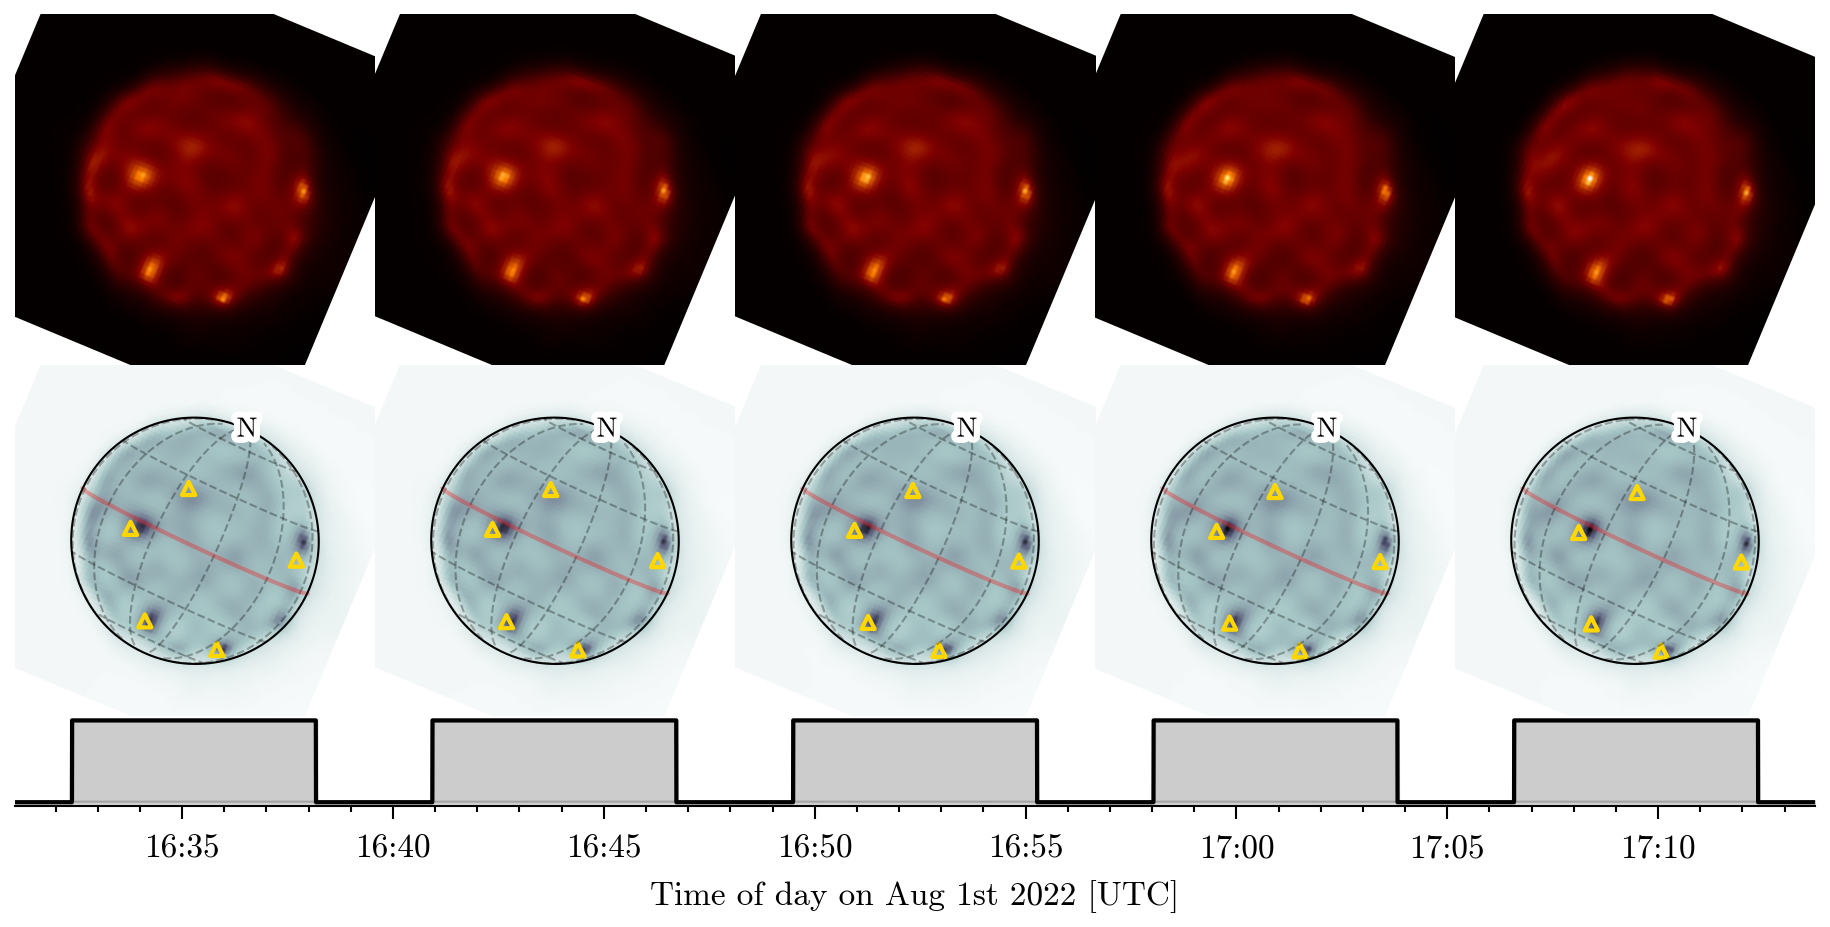

In [ ]:
%matplotlib inline

rang, exposings = get_exposing(sci_files, eps=1.35)
exposing = np.sum(exposings, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(6, 3), gridspec_kw={"hspace": 0.0, "wspace": 0.0, "left":0, "right":1.})

# Adjust layout first
plt.tight_layout()

fig.subplots_adjust(bottom=0.1)  # Shift everything up to leave space for time axis

# Create a new axes for the time plot — [left, bottom, width, height] in figure fraction
time_ax = fig.add_axes([0., 0.0, 1., .1])  # Tune values if needed

for col, exp, file in zip(range(len(sci_fits)), sci_fits, sci_files):

    axes[0][col].axis("off")
    axes[1][col].axis("off")

    dist = result_model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    # axes[0][col].set(title=convert_time(time))

    c0 = plot_result(
        axes[0][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-exp.parang,
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        axes[1][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-exp.parang,
        scale=source_size / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    # eps = 3e-2
    # for i, (x, y) in enumerate(coords):  # i should now correctly track the index
    #     axes[1][col].text(
    #         x - eps,
    #         y,
    #         f"{i+1}",
    #         fontsize=7,
    #         c="gold",
    #         fontfamily="monospace",
    #         fontweight="bold",
    #     )  # Use i in the label

time_ax.plot(rang, exposing, 'k')
time_ax.fill_between(rang, exposing, color='k', alpha=0.2)
time_ax.spines['top'].set_visible(False)
time_ax.spines['right'].set_visible(False)
time_ax.spines['left'].set_visible(False)
time_ax.tick_params(axis="x", which="both", top=False)
time_ax.set(
    xlim=(rang.min(), rang.max()),
    xlabel="Time of day on Aug 1st 2022 [UTC]",  # Set the x-axis label
    xticks=range(35, 75, 5),
    xticklabels=["16:35", "16:40", "16:45", "16:50", "16:55", "17:00", "17:05", "17:10"],
    yticks=[],
    )


    # time_ax.axis("off")

plt.show()

# plt.show()

In [ ]:
def lcurve_sweep(
    regulariser: str,  # e.g. "L1", "L2", "TV", "QV", "ME", "SF"
    coeffs,
    reg_func_dict,
    trainer,
    model,
    optimisers,
    epochs,
    exposures,
):
    """
    Function to find an optimal regularisation hyperparameter using the l-curve method.
    """

    @zdx.filter_jit
    def calc_balance(model, exposures, args, coeff):
        return np.array(
            [
                dorito.stats.prior_data_balance(model, exp, args, coeff)
                for exp in exposures
            ]
        ).sum(0)

    balances = []
    results = []

    args = {"reg_dict": {regulariser: None}, "reg_func_dict": reg_func_dict}

    for coeff in coeffs:
        print(f"Regulariser: {regulariser}, Coefficient: {coeff:.2e}")

        args["reg_dict"][regulariser] = coeff

        result = trainer.train(
            model=model,
            optimisers=optimisers,
            epochs=epochs,
            batches=exposures,
            args=args,
        )

        balance = calc_balance(result.model, exposures, args, coeff)
        balances.append(balance)

        results.append(result)

    return results, np.array(balances).T

In [ ]:
coeffs = 10 ** np.arange(-6.0, -2.5, 0.5)

results, balances = lcurve_sweep(
    "L1",
    coeffs,
    {"L1": L1_REG},
    trainer=trainer,
    model=model,
    optimisers=config,
    epochs=500,
    exposures=fits,
)

for res, coeff in zip(results, coeffs):
    print(f"{coeff:.2e}")
    summarise_reconstruction(res.model, fits, result=res)

In [ ]:
# for res, coeff in zip(results, coeffs):
#     print(f"{coeff:.2e}")
#     summarise_reconstruction(res.model, fits, result=res)

In [ ]:
def plot_lcurve(balances, coeffs, regulariser):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    sc = ax.scatter(
        balances[0],
        balances[1] / coeffs,
        # linestyle="--",
        # marker="o",
        s=3,
        c=coeffs,
        norm=mpl.colors.LogNorm(),
        cmap="tab20",
    )
    ax.set(
        xscale="log",
        yscale="log",
        xlabel="Data Likelihood",
        ylabel="Prior Likelihood",
        title=f"L-curve: {regulariser}",
    )
    plt.colorbar(
        sc,
        label=r"Regularisation Coefficient $\lambda$",
        ticks=10.0 ** np.arange(-10, 15, 1),
    )
    plt.tight_layout()
    plt.show()


plot_lcurve(balances, coeffs, "L1 on wavelets")

In [ ]:
for r, c in zip(results, coeffs):

    ticks = [-0.5, 0, 0.5]
    exp = sci_fits[0]

    try:
        dist = r.model.get_distribution(exp)
    except:
        dist = exp.get_distribution(r.model)

    fig, ax = plt.subplots(figsize=(3, 2))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=pscale(model),
        roll_angle_degrees=-rolls[exp.filename],
        cmap="afmhot_u",
        power=0.3,
        vmin=0,
        ticks=ticks,
    )
    # print(b)
    ax.set(title=f"{c:.2e}")
    ax.axis("off")
    plt.show()